In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
#TASK 1
#i.
# Loading the dataset
df = pd.read_csv('customer_churn_nn.csv')
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [4]:
#ii.
print("Shape of Dataset:")
print(df.shape)

Shape of Dataset:
(2000, 17)


In [5]:
#iii.
print("\nData Types:")
print(df.dtypes)


Data Types:
customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object


In [6]:
#iv.
print("\nMissing Values:") #Checking for missing values
print(df.isnull().sum())


Missing Values:
customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64


In [7]:
#v.
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
       tenure_months  monthly_charges_inr  avg_login_days_per_month  \
count    2000.000000          2000.000000               2000.000000   
mean       25.362000           766.487295                 18.099000   
std        14.128651           393.420070                  5.400628   
min         1.000000           255.450000                  0.000000   
25%        15.000000           427.782500                 15.000000   
50%        23.000000           688.355000                 18.000000   
75%        33.000000          1007.372500                 22.000000   
max        72.000000          2156.520000                 30.000000   

       support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
count                   2000.000000         2000.000000    2000.000000   
mean                       1.953000            3.555000      90.007625   
std                        1.463852            3.885682      53.215719   
min                        0.000000       

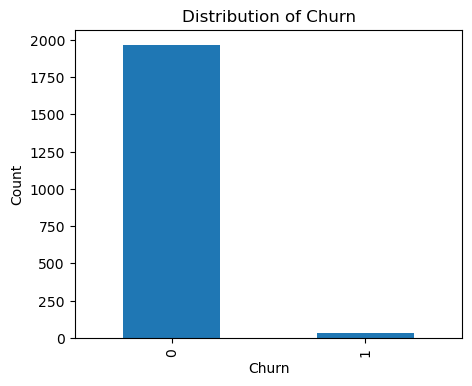

In [8]:
#Distribution of the target variable
plt.figure(figsize=(5,4))

df['churn'].value_counts().plot(kind='bar')

plt.title("Distribution of Churn")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

In [9]:
#TASK 2
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [10]:
#i.
categorical_cols = df.select_dtypes(include=['object']).columns

print(categorical_cols)
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

Index(['customer_id', 'region', 'plan_type', 'contract_type',
       'payment_method'],
      dtype='object')


In [11]:
#ii.
X = df.drop('churn', axis=1)
y = df['churn']
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (1600, 16)
Testing Data Shape: (400, 16)


In [12]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [14]:
model = Sequential()
model.add(Dense(
    16,
    activation='relu',
    input_dim=X_train.shape[1]
))

In [15]:
model.add(Dense(
    8,
    activation='relu'
))
model.add(Dense(
    1,
    activation='sigmoid'
))

In [16]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16)                  │             272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 417 (1.63 KB)

 Trainable params: 417 (1.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#TASK 4

In [18]:
#i.
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.1273 - loss: 0.9895 - val_accuracy: 0.2844 - val_loss: 0.7961
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6094 - loss: 0.6731 - val_accuracy: 0.8500 - val_loss: 0.5938
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9484 - loss: 0.5136 - val_accuracy: 0.9656 - val_loss: 0.4710
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9836 - loss: 0.4044 - val_accuracy: 0.9781 - val_loss: 0.3798
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9867 - loss: 0.3201 - val_accuracy: 0.9781 - val_loss: 0.3057
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9867 - loss: 0.2523 - val_accuracy: 0.9781 - val_loss: 0.2482
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9867 - loss: 0.2005 - val_accuracy: 0.9781 - val_loss: 0.2052
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9867 - loss: 0.1623 - val_accuracy: 0.9781 - val_loss

In [20]:
#ii
#Experiment 1

model1 = Sequential()

model1.add(Dense(16, activation='relu', input_dim=X_train.shape[1]))
model1.add(Dense(8, activation='relu'))
model1.add(Dense(1, activation='sigmoid'))

model1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history1 = model1.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

loss1, acc1 = model1.evaluate(X_test, y_test)

print("Experiment 1 Accuracy:", acc1)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9825 - loss: 0.0854  
Experiment 1 Accuracy: 0.9825000166893005


In [21]:
#Experiment 2
model2 = Sequential()

model2.add(Dense(32, activation='relu', input_dim=X_train.shape[1]))
model2.add(Dense(16, activation='relu'))
model2.add(Dense(1, activation='sigmoid'))

model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

loss2, acc2 = model2.evaluate(X_test, y_test)

print("Experiment 2 Accuracy:", acc2)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9775 - loss: 0.1246  
Experiment 2 Accuracy: 0.9775000214576721


In [22]:
#Experiment 3
model3 = Sequential()

model3.add(Dense(16, activation='tanh', input_dim=X_train.shape[1]))
model3.add(Dense(8, activation='tanh'))
model3.add(Dense(1, activation='sigmoid'))

model3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history3 = model3.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

loss3, acc3 = model3.evaluate(X_test, y_test)

print("Experiment 3 Accuracy:", acc3)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9800 - loss: 0.1215  
Experiment 3 Accuracy: 0.9800000190734863


In [23]:
import pandas as pd

results = pd.DataFrame({
    'Experiment': ['Exp 1', 'Exp 2', 'Exp 3'],
    'Hidden Layers': ['16-8', '32-16', '16-8'],
    'Activation': ['ReLU', 'ReLU', 'Tanh'],
    'Epochs': [50, 50, 100],
    'Batch Size': [32, 32, 32],
    'Test Accuracy': [acc1, acc2, acc3]
})

print(results)

  Experiment Hidden Layers Activation  Epochs  Batch Size  Test Accuracy
0      Exp 1          16-8       ReLU      50          32         0.9825
1      Exp 2         32-16       ReLU      50          32         0.9775
2      Exp 3          16-8       Tanh     100          32         0.9800
